<a href="https://colab.research.google.com/github/miriamamin1213-ux/Seed42_Models/blob/main/CNN_Hecktor_NoSmote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 18.7MB/s]


(423, 12)
HPV Status
1.0    320
0.0     18
Name: count, dtype: int64
HPV Status
1.0    80
0.0     5
Name: count, dtype: int64

Training class distribution - No SMOTE:
HPV Status
1.0    320
0.0     18
Name: count, dtype: int64


/tmp/ipykernel_6937/17046233.py:104: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["T-stage"] = df["T-stage"].replace({
/tmp/ipykernel_6937/17046233.py:112: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["N-stage"] = df["N-stage"].replace({
/tmp/ipykernel_6937/17046233.py:119: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silen

Epoch 50, Train=0.6245, Test=0.6190
Epoch 100, Train=0.4944, Test=0.4930
Epoch 150, Train=0.4016, Test=0.4105
Epoch 200, Train=0.3567, Test=0.3744
Epoch 250, Train=0.3292, Test=0.3511
Epoch 300, Train=0.3034, Test=0.3264
Epoch 350, Train=0.2775, Test=0.3001
Epoch 400, Train=0.2530, Test=0.2756
Epoch 450, Train=0.2317, Test=0.2562
Epoch 500, Train=0.2166, Test=0.2430

Best Test Loss = 0.243
Best Epoch = 500

Classification Report

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         5
           1     0.9412    1.0000    0.9697        80

    accuracy                         0.9412        85
   macro avg     0.4706    0.5000    0.4848        85
weighted avg     0.8858    0.9412    0.9127        85

Confusion Matrix
[[ 0  5]
 [ 0 80]]

Accuracy:            0.9412
Balanced Accuracy:   0.5000
F1-score:            0.9697
AUC:                 0.9075

MODEL 27 SUMMARY
Architecture : Conv16-FC32-FC16-2
Input Features : 11
Learning Rate : 0.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


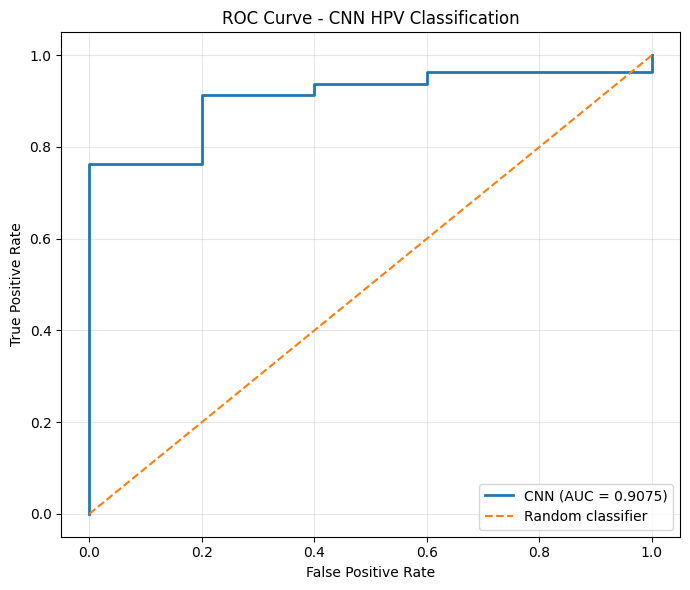

AUC: 0.9075


In [1]:
# ============================================================
# CNN42_Hecktor - NO SMOTE
# ============================================================

!pip install -q gdown

import gdown

gdown.download(
    id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",
    output="HPV2025.xlsx",
    quiet=False
)

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score
)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

def seed_everything(seed=42):

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    np.random.seed(seed)
    random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    torch.use_deterministic_algorithms(True, warn_only=True)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


SEED = 42
seed_everything(SEED)


# ------------------------------------------------------------
# Read Dataset
# ------------------------------------------------------------

df = pd.read_excel("HPV2025.xlsx")

df = df.dropna(subset=["HPV Status"])


tobacco_mode = df["Tobacco Consumption"].mode()[0]

df["Tobacco Consumption"] = df[
    "Tobacco Consumption"
].fillna(tobacco_mode)


alcohol_mode = df["Alcohol Consumption"].mode()[0]

df["Alcohol Consumption"] = df[
    "Alcohol Consumption"
].fillna(alcohol_mode)


df = df.drop(
    columns=[
        "PatientID",
        "CenterID",
        "Task 1",
        "Task 2",
        "Task 3"
    ]
)

df = df.dropna()

print(df.shape)


# ------------------------------------------------------------
# Encode stages
# ------------------------------------------------------------

df["T-stage"] = df["T-stage"].replace({
    "T0": 0,
    "T1": 1,
    "T2": 2,
    "T3": 3,
    "T4": 4
})

df["N-stage"] = df["N-stage"].replace({
    "N0": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3
})

df["M-stage"] = df["M-stage"].replace({
    "M0": 0,
    "M1": 1
})


# ------------------------------------------------------------
# Features
# ------------------------------------------------------------

X = df[
    [
        "Age",
        "Gender",
        "Tobacco Consumption",
        "Alcohol Consumption",
        "Performance Status",
        "Relapse",
        "RFS",
        "Treatment",
        "T-stage",
        "N-stage",
        "M-stage"
    ]
]

y = df["HPV Status"]


# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print(y_train.value_counts())

print(y_test.value_counts())


# ------------------------------------------------------------
# Standardisation
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ------------------------------------------------------------
# NO SMOTE
# ------------------------------------------------------------

print("\nTraining class distribution - No SMOTE:")

print(y_train.value_counts())


# ------------------------------------------------------------
# Torch
# ------------------------------------------------------------

X_train = torch.FloatTensor(X_train)

X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(
    y_train.to_numpy()
)

y_test = torch.LongTensor(
    y_test.to_numpy()
)


# Conv1D requires channel dimension

X_train = X_train.unsqueeze(1)

X_test = X_test.unsqueeze(1)


# ------------------------------------------------------------
# MODEL 27
# Conv16-FC32-FC16-FC2
# ------------------------------------------------------------

class HPVCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            16 * 11,
            32
        )

        self.fc2 = nn.Linear(
            32,
            16
        )

        self.fc3 = nn.Linear(
            16,
            2
        )

    def forward(self, x):

        x = self.conv1(x)

        x = self.relu(x)

        x = self.flatten(x)

        x = self.relu(
            self.fc1(x)
        )

        x = self.relu(
            self.fc2(x)
        )

        x = self.fc3(x)

        return x


model = HPVCNN()


weights = torch.tensor(
    [2.0, 1.0],
    dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)


# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------

epochs = 500

best_test_loss = float("inf")

best_epoch = 0


for epoch in range(epochs):

    model.train()

    outputs = model(X_train)

    train_loss = criterion(
        outputs,
        y_train
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()


    model.eval()

    with torch.no_grad():

        test_outputs = model(X_test)

        test_loss = criterion(
            test_outputs,
            y_test
        )


    if test_loss.item() < best_test_loss:

        best_test_loss = test_loss.item()

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_model27_no_smote.pth"
        )


    if (epoch + 1) % 50 == 0:

        print(

            f"Epoch {epoch + 1}, "

            f"Train={train_loss.item():.4f}, "

            f"Test={test_loss.item():.4f}"

        )


print()

print(
    "Best Test Loss =",
    round(best_test_loss, 4)
)

print(
    "Best Epoch =",
    best_epoch
)


# ------------------------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------------------------

model.load_state_dict(
    torch.load(
        "best_model27_no_smote.pth"
    )
)

model.eval()


with torch.no_grad():

    outputs = model(X_test)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    predicted = torch.argmax(
        outputs,
        dim=1
    )


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print()

print("Classification Report\n")

print(

    classification_report(

        y_test.numpy(),

        predicted.numpy(),

        digits=4

    )

)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(

    y_test.numpy(),

    predicted.numpy()

)

print("Confusion Matrix")

print(cm)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

bal_acc = balanced_accuracy_score(

    y_test.numpy(),

    predicted.numpy()

)


f1 = f1_score(

    y_test.numpy(),

    predicted.numpy()

)


auc = roc_auc_score(

    y_test.numpy(),

    probabilities[:, 1].numpy()

)


accuracy = (

    predicted.eq(y_test)
    .sum()
    .item()
    /
    len(y_test)

)


print()

print(
    f"Accuracy:            {accuracy:.4f}"
)

print(
    f"Balanced Accuracy:   {bal_acc:.4f}"
)

print(
    f"F1-score:            {f1:.4f}"
)

print(
    f"AUC:                 {auc:.4f}"
)


# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

print()

print("====================================")

print("MODEL 27 SUMMARY")

print("====================================")

print(
    "Architecture : Conv16-FC32-FC16-2"
)

print(
    "Input Features : 11"
)

print(
    "Learning Rate : 0.0001"
)

print(
    "Optimiser : Adam"
)

print(
    "Class Weights : [2.0,1.0]"
)

print(
    "SMOTE : No"
)

print(
    "Epochs : 500"
)

print(
    "Best Epoch :",
    best_epoch
)

print(
    "Best Test Loss :",
    round(best_test_loss, 4)
)

print(
    "Training Patients :",
    len(y_train)
)

print(
    "Test Patients :",
    len(y_test)
)

print(
    "Seed :",
    SEED
)


# ------------------------------------------------------------
# ROC CURVE
# ------------------------------------------------------------

from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt


# HPV-positive probability

y_score = probabilities[:, 1].numpy()


# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(

    y_test.numpy(),

    y_score

)


# Calculate AUC

auc = roc_auc_score(

    y_test.numpy(),

    y_score

)


# Plot ROC curve

plt.figure(figsize=(7, 6))


plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f'CNN (AUC = {auc:.4f})'

)


# Random classifier

plt.plot(

    [0, 1],

    [0, 1],

    linestyle='--',

    linewidth=1.5,

    label='Random classifier'

)


plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve - CNN HPV Classification'
)

plt.legend(
    loc='lower right'
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


print(
    f"AUC: {auc:.4f}"
)